# **KNN_personal_loan**

## 1. **Import libraries**

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

# 2.**Load Bank Personal Loan Modelling dataset & explore**

In [3]:
loan_dataset = pd.read_csv("Loan Modelling Thera Bank.csv")
loan_dataset

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [4]:
loan_dataset.keys()

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [5]:
loan_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [6]:
loan_dataset.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


## 3.**Data visualization**

c:\Users\bpscm\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


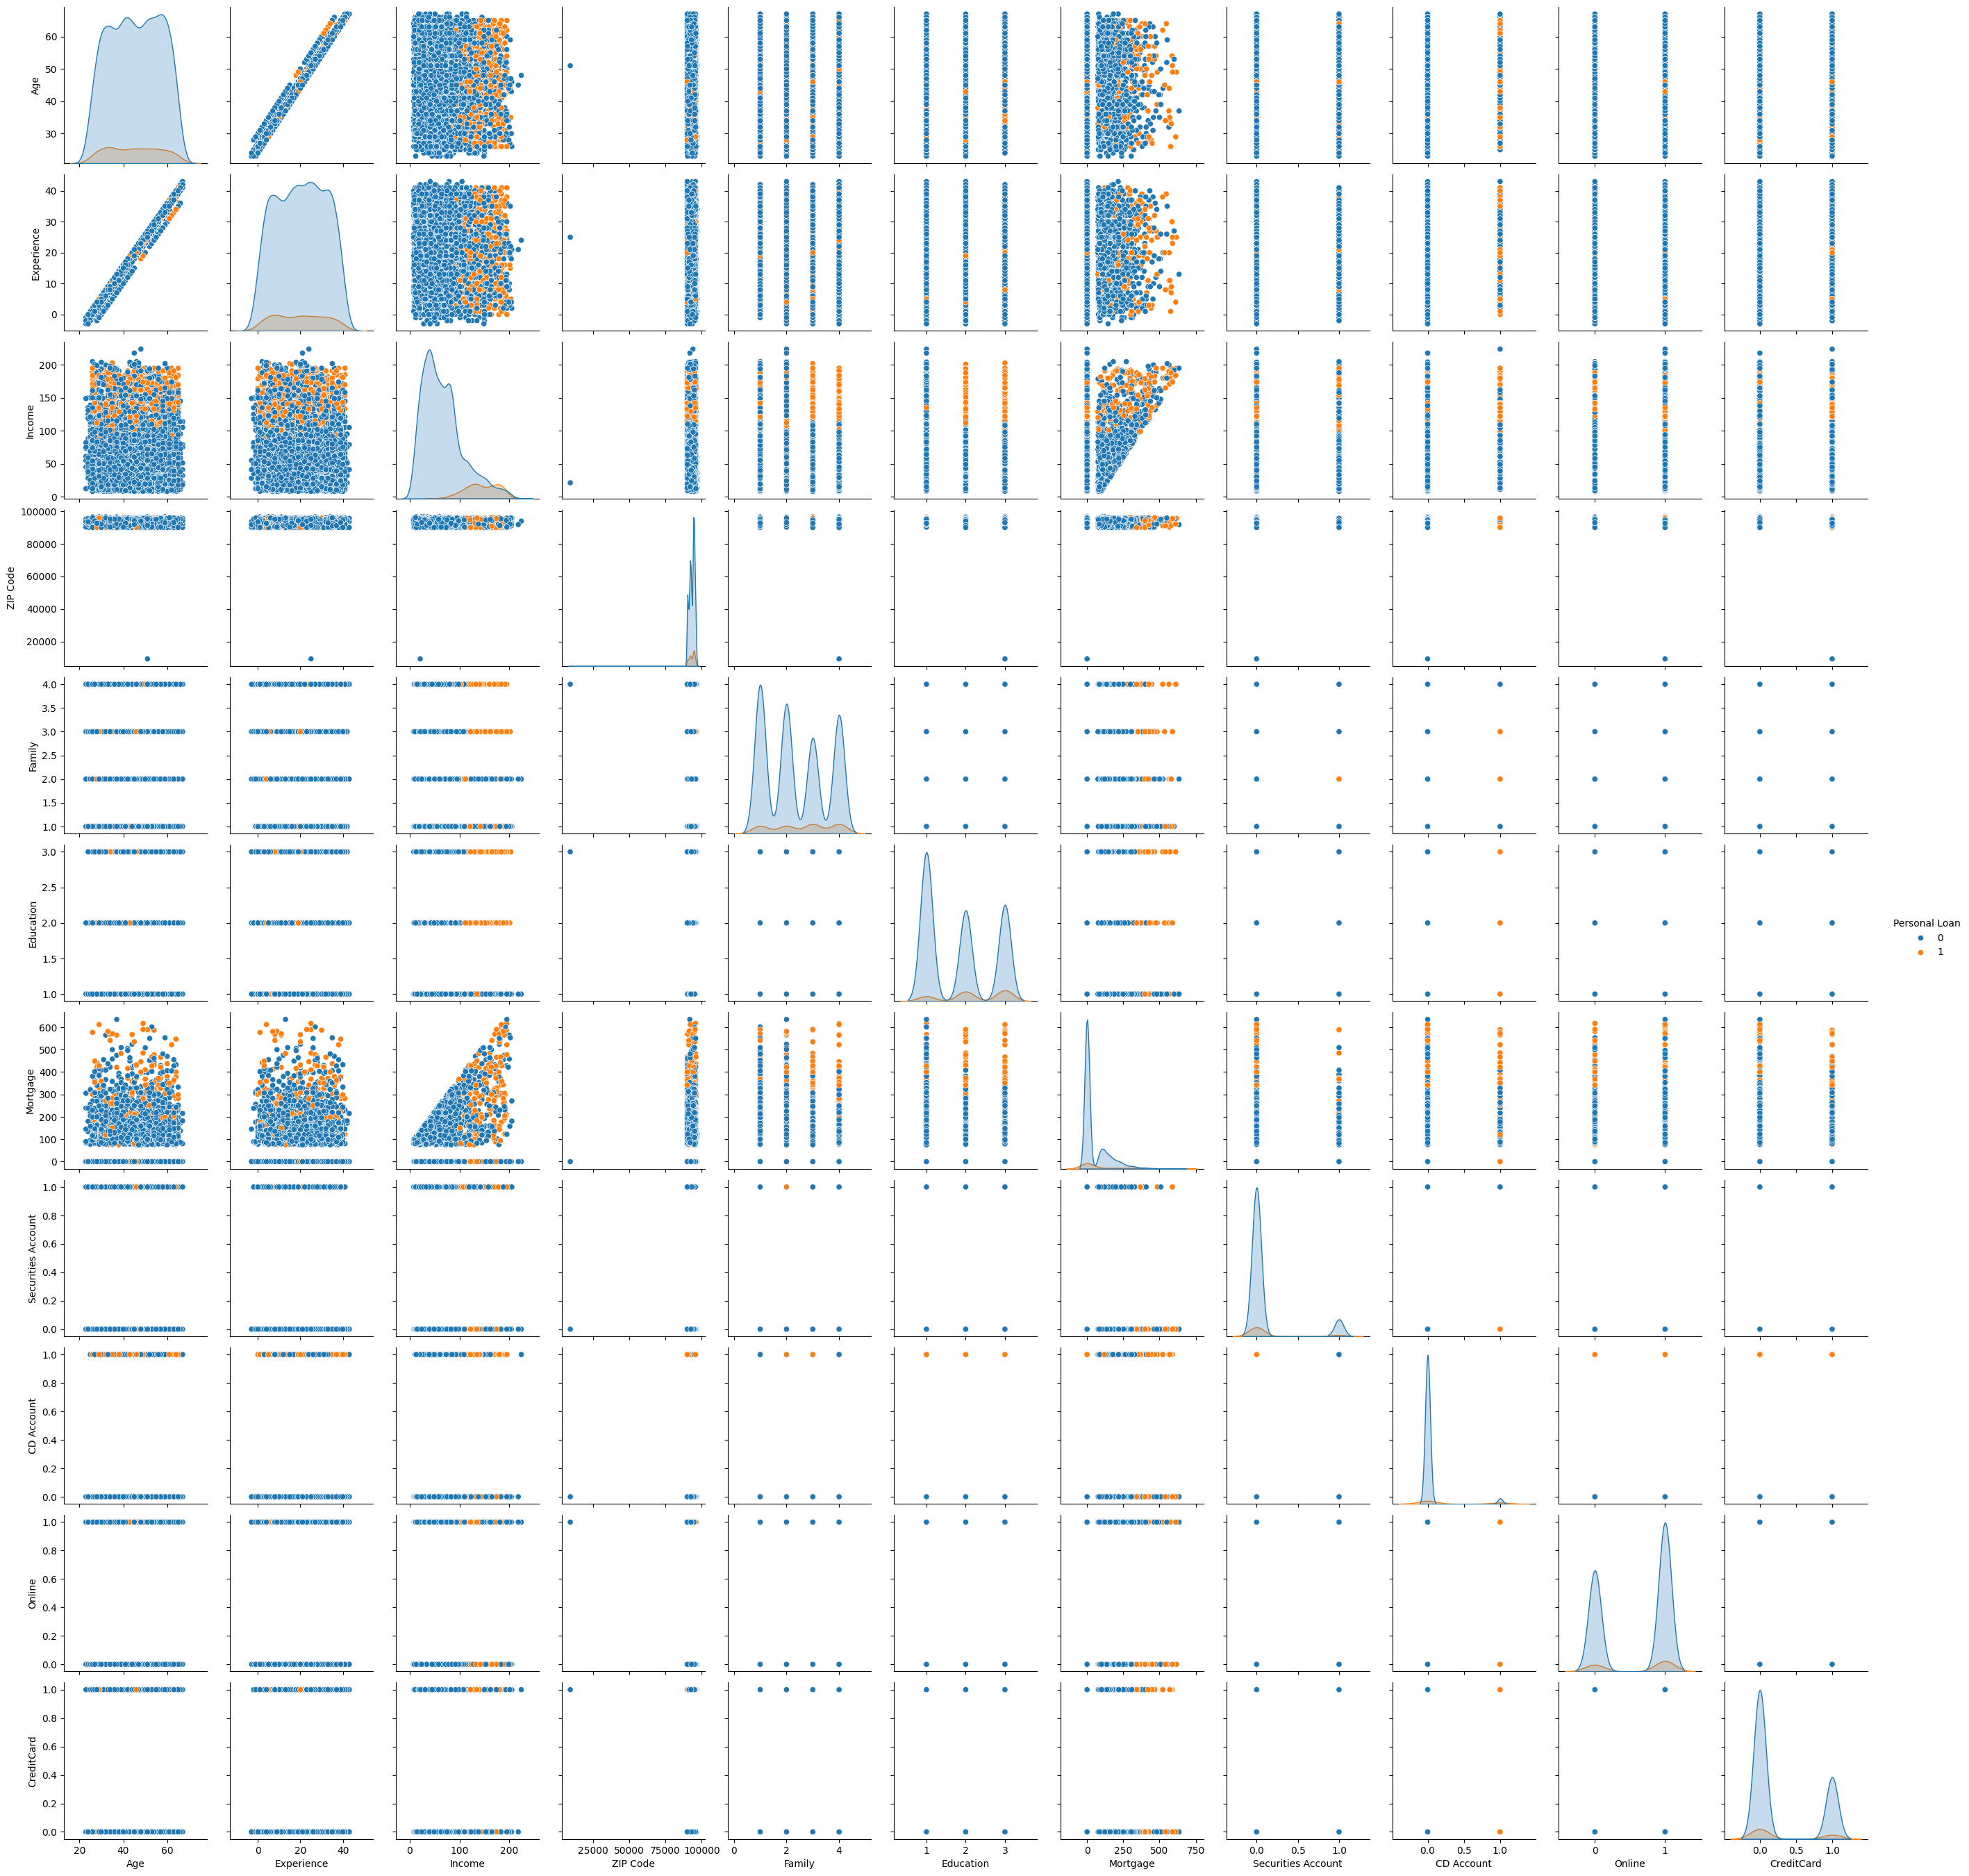

In [7]:
sns.pairplot(loan_dataset,hue='Personal Loan', vars=['Age','Experience','Income','ZIP Code','Family','Education','Mortgage','Securities Account','CD Account','Online','CreditCard'])

<Axes: xlabel='Personal Loan', ylabel='count'>

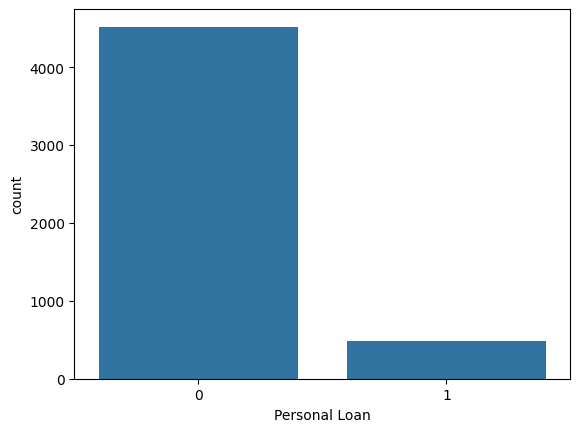

In [8]:
sns.countplot(x=loan_dataset['Personal Loan'], order=[0, 1])

<Axes: >

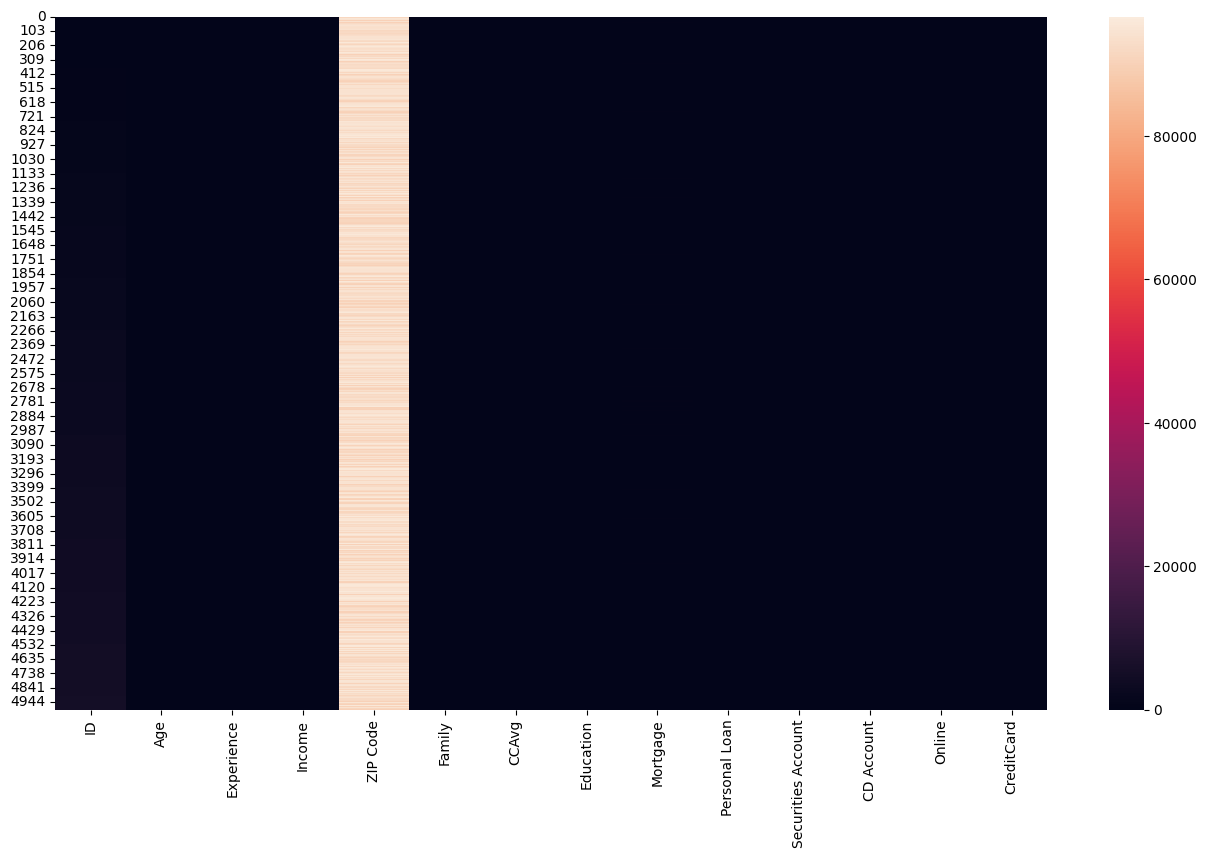

In [9]:
plt.figure(figsize=(16,9))
sns.heatmap(loan_dataset)

<Axes: >

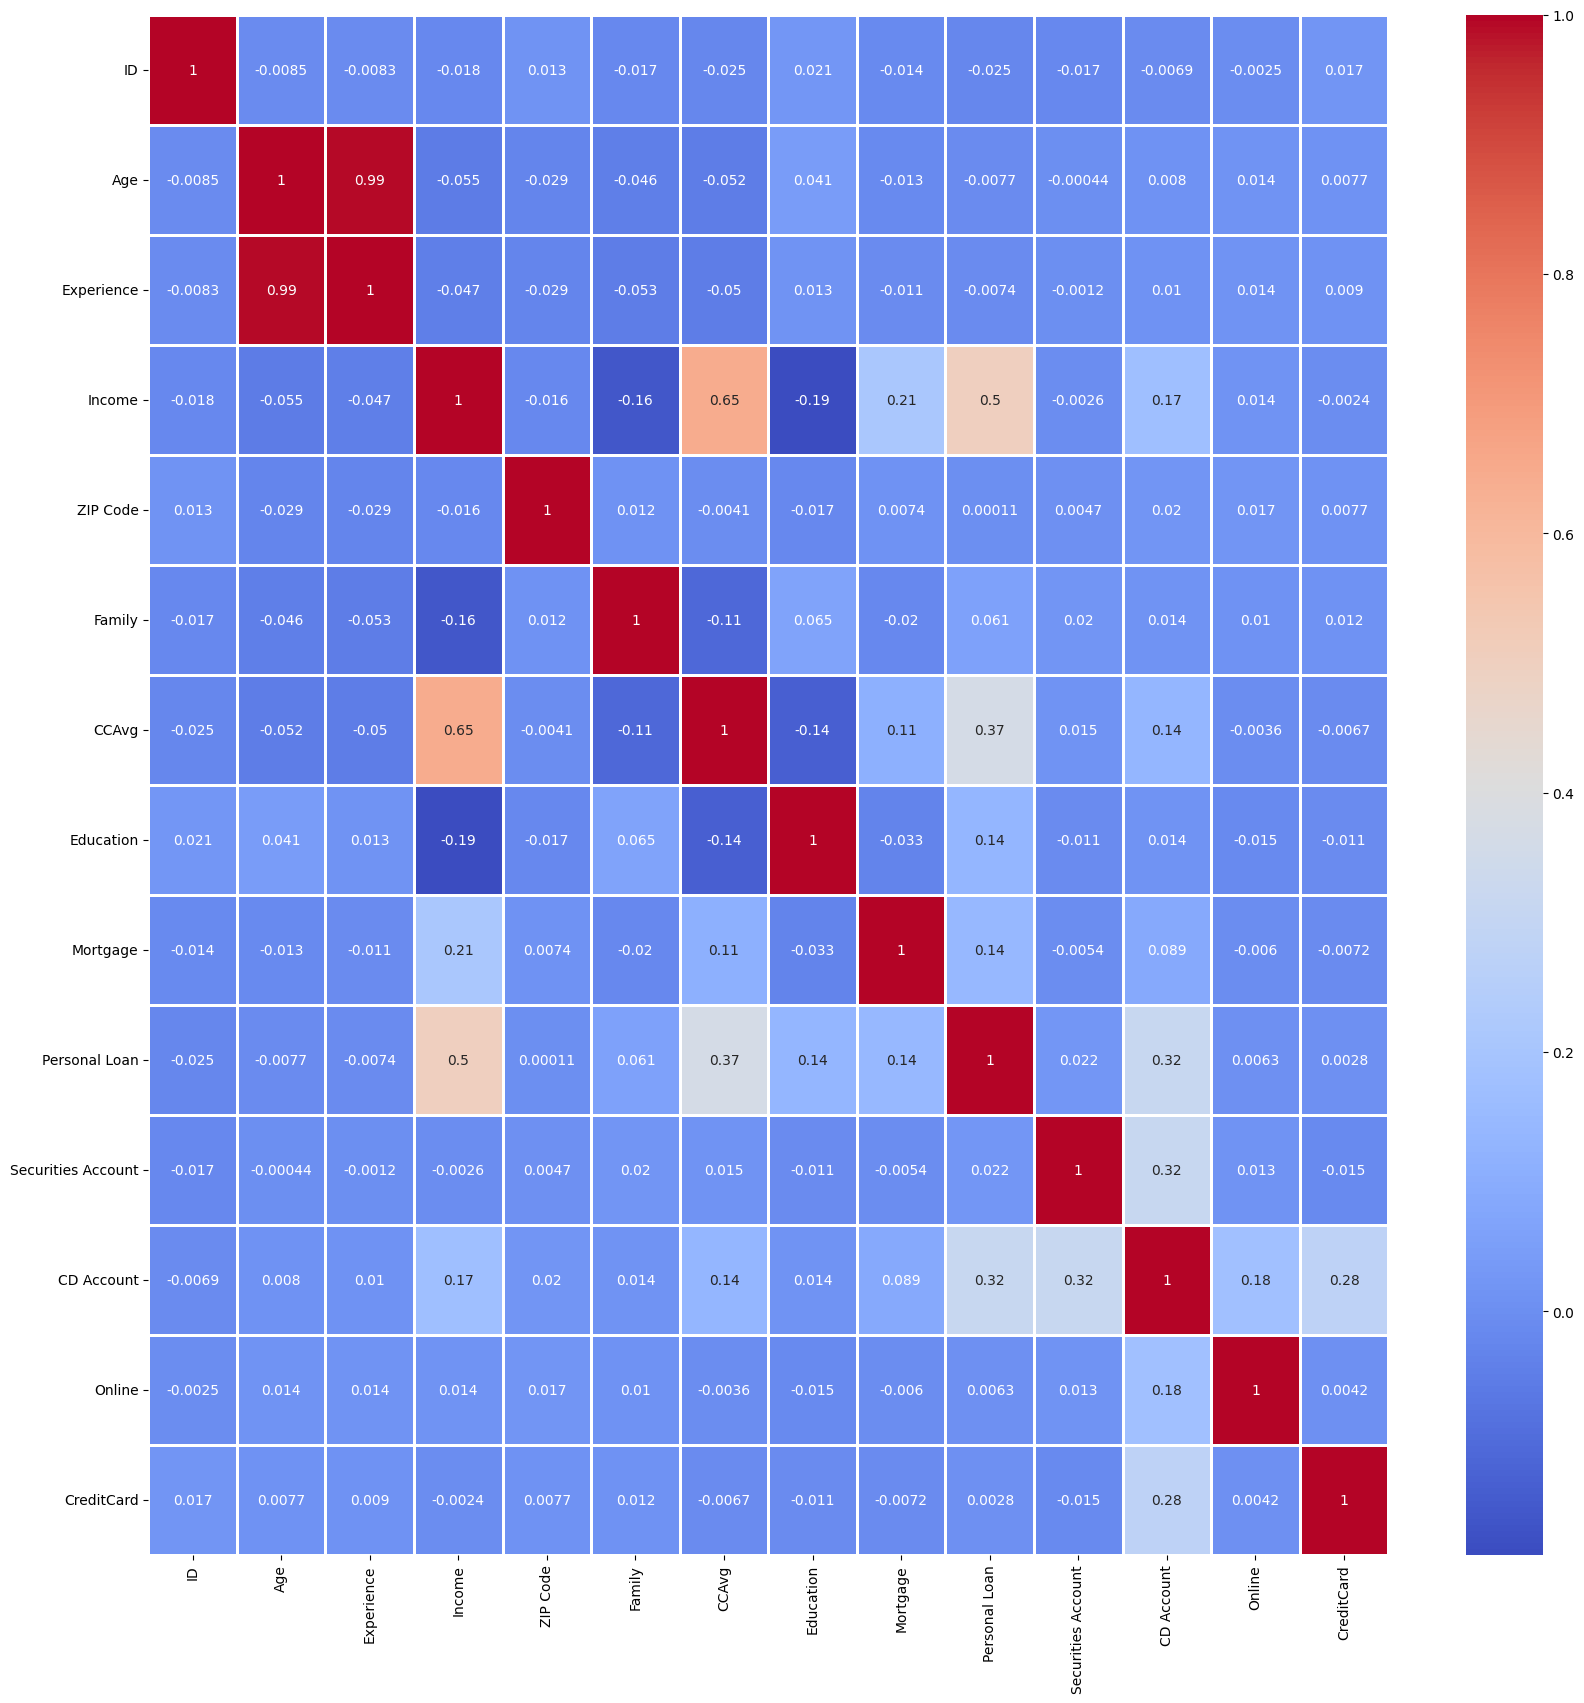

In [10]:
plt.figure(figsize=(20,20))
sns.heatmap(loan_dataset.corr(), annot=True, cmap='coolwarm',linewidths=2)

## 4. **Data processing**

*Normalization*

In [11]:
X = loan_dataset.drop(['Personal Loan', 'ID'],axis=1)
X = (X-X.min())/(X.max()-X.min())
X

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
0,0.045455,0.086957,0.189815,0.936527,1.000000,0.16,0.0,0.000000,1.0,0.0,0.0,0.0
1,0.500000,0.478261,0.120370,0.924872,0.666667,0.15,0.0,0.000000,1.0,0.0,0.0,0.0
2,0.363636,0.391304,0.013889,0.977892,0.000000,0.10,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.272727,0.260870,0.425926,0.970931,0.000000,0.27,0.5,0.000000,0.0,0.0,0.0,0.0
4,0.272727,0.239130,0.171296,0.939080,1.000000,0.10,0.5,0.000000,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.136364,0.130435,0.148148,0.954731,0.000000,0.19,1.0,0.000000,0.0,0.0,1.0,0.0
4996,0.159091,0.152174,0.032407,0.947174,1.000000,0.04,0.0,0.133858,0.0,0.0,1.0,0.0
4997,0.909091,0.913043,0.074074,0.958463,0.333333,0.03,1.0,0.000000,0.0,0.0,0.0,0.0
4998,0.954545,0.934783,0.189815,0.924242,0.666667,0.05,0.5,0.000000,0.0,0.0,1.0,0.0


In [12]:
X.describe()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,0.507691,0.502274,0.304510,0.959946,0.465467,0.193794,0.440500,0.088974,0.104400,0.06040,0.596800,0.294000
std,0.260526,0.249303,0.213119,0.024293,0.382554,0.174766,0.419935,0.160179,0.305809,0.23825,0.490589,0.455637
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.272727,0.282609,0.143519,0.945732,0.000000,0.070000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,0.500000,0.500000,0.259259,0.963203,0.333333,0.150000,0.500000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,0.727273,0.717391,0.416667,0.976610,0.666667,0.250000,1.000000,0.159055,0.000000,0.00000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


<Axes: >

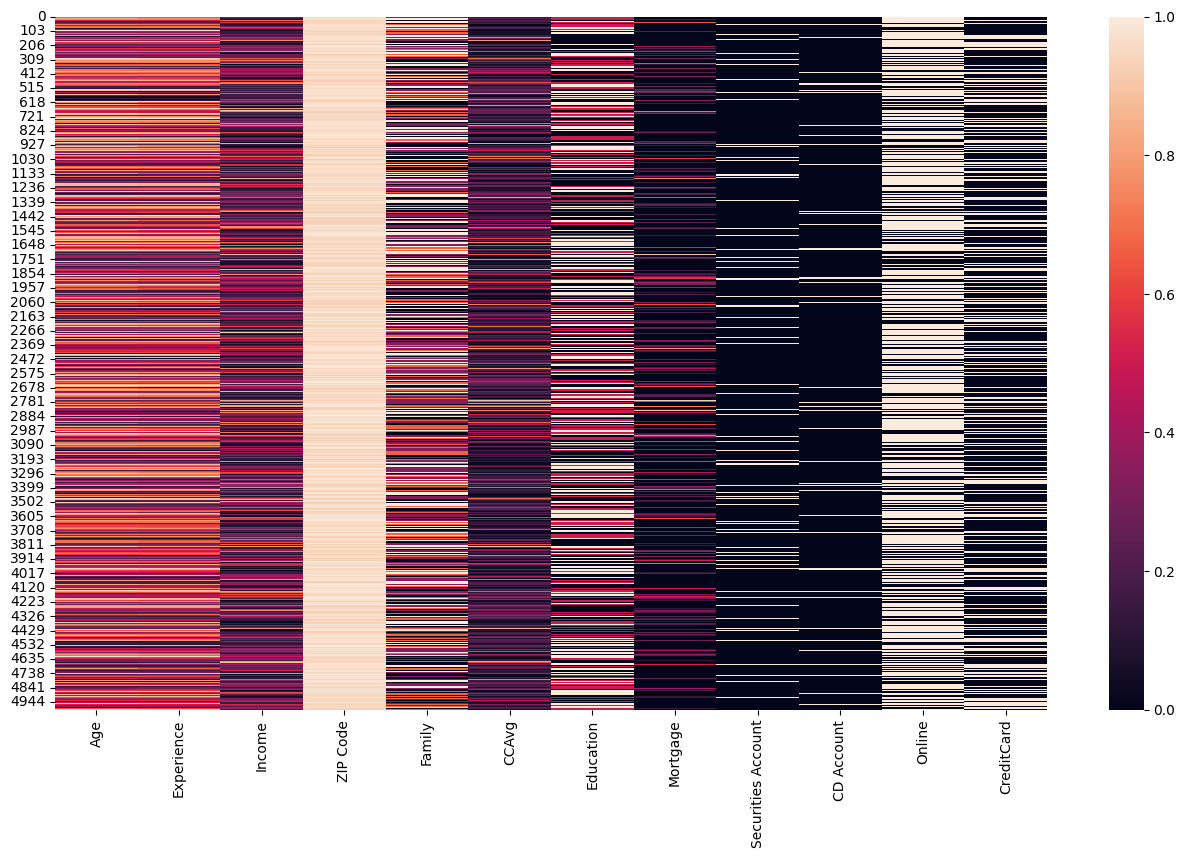

In [13]:
plt.figure(figsize=(16,9))
sns.heatmap(X)

In [14]:
y = loan_dataset['Personal Loan']
y

0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: Personal Loan, Length: 5000, dtype: int64

### 4.1 Split data set into 1 part: training & testing:
 - Training: 80% Data set
 - Testing: 20% Data set

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=5)
print("Train Dataset = ", X_train.shape,y_train.shape)
print("Test Dataset = ", X_test.shape, y_test.shape)

Train Dataset =  (4000, 12) (4000,)
Test Dataset =  (1000, 12) (1000,)


## 5.**Personal Loan Modeling**

In [16]:
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

%matplotlib inline

## 6. **K-Nearest Neighbor Classifier**

## 7. **Using KNN Classifier**

Goals:
 - Build KNN model using sklearn lib
 - Apply, understand how to use KNN to solve real-life problems (e.g. classify)
 - Using Accuracy, Precision, Recall Score to assess quality of the model

Problem: A data set have not been labeled yet -> Wonder how to label them -> Training a ML model to classify
Data set: Bank Personal Loan Modeling

**Problem**:
 - INPUT: 1 data set X = $[x_1,x_2,...,x_n]$
 - OUTPUT: label y as 0 or 1

In [17]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline

## 8. **KNN Model**

Using KNN lib to train. n_neighbors = 5; Euclide p=2

In [18]:
knn_classifier = KNeighborsClassifier(n_neighbors= 10, metric ='minkowski',p=2,weights='distance')
knn_classifier.fit(X_train,y_train)

,n_neighbors,10
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## 9. **Testing KNN model**

### 9.1 Assess w metrics

In [19]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

print("Testing...\n")
y_pred_knn = knn_classifier.predict(X_test)
print('Accuracy: ', accuracy_score(y_test, y_pred_knn))
print('Precision: ', precision_score(y_test, y_pred_knn))
print('Recall: ', recall_score(y_test, y_pred_knn))

Testing...

Accuracy:  0.952
Precision:  0.9166666666666666
Recall:  0.5


## 10. **Model Selection**

### 10.1 Select number of neighbors

- Change the number of neighbors to find the best value (best results)

### 10.2 Select attributes

- Try to drop each attribute, observe how that affect the result
- What attributes should be used to have the best result?

### 10.3 Select distance metrics

- minkowski, manhattan, euclidean, chebyshev

Solve: 10.1

In [20]:
k_neighbors = [1,2,3,4,5,6,7,8,9,10,15,20,30]
models = []
for i in k_neighbors:
    knn_classifier = KNeighborsClassifier(n_neighbors = i, metric ='minkowski', p=2, weights='distance')
    knn_classifier.fit(X_train,y_train)
    models.append(knn_classifier)

In [21]:
acc_score, pre_score, re_score = [],[],[]
for model in models:
    y_pred = model.predict(X_test)
    acc_score.append(accuracy_score(y_test,y_pred))
    pre_score.append(precision_score(y_test,y_pred))
    re_score.append(recall_score(y_test,y_pred))

acc_score,pre_score,re_score

([0.967,
  0.967,
  0.962,
  0.957,
  0.957,
  0.955,
  0.953,
  0.954,
  0.952,
  0.952,
  0.949,
  0.945,
  0.939],
 [0.9104477611940298,
  0.9104477611940298,
  0.9032258064516129,
  0.8947368421052632,
  0.8947368421052632,
  0.8771929824561403,
  0.9019607843137255,
  0.9038461538461539,
  0.9166666666666666,
  0.9166666666666666,
  0.9302325581395349,
  0.9230769230769231,
  0.9354838709677419],
 [0.6931818181818182,
  0.6931818181818182,
  0.6363636363636364,
  0.5795454545454546,
  0.5795454545454546,
  0.5681818181818182,
  0.5227272727272727,
  0.5340909090909091,
  0.5,
  0.5,
  0.45454545454545453,
  0.4090909090909091,
  0.32954545454545453])

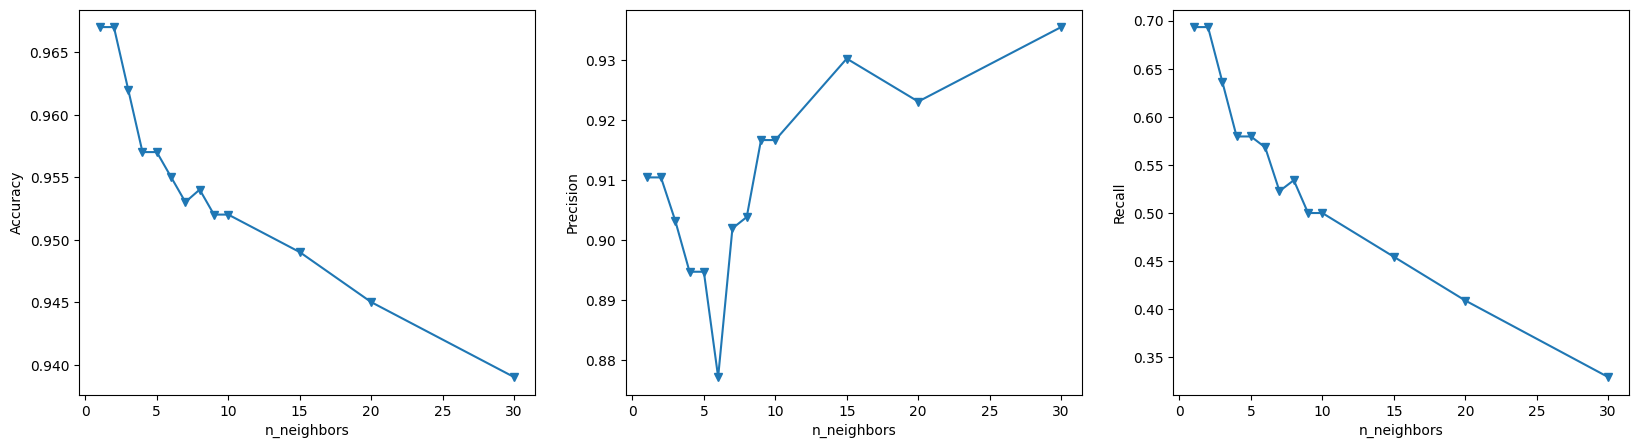

In [23]:
fig, axs = plt.subplots(1,3,figsize=(20,5))

axs[0].plot(k_neighbors, acc_score, marker="v")
axs[0].set_xlabel("n_neighbors")
axs[0].set_ylabel("Accuracy")
# axs[0].set_title("Ảnh hưởng của số lượng láng giềng")
axs[1].plot(k_neighbors,pre_score,marker="v")
axs[1].set_xlabel("n_neighbors")
axs[1].set_ylabel("Precision")
# axs[1].set_title("Ảnh hưởng của số lượng láng giềng")
axs[2].plot(k_neighbors, re_score, marker= "v")
axs[2].set_xlabel("n_neighbors")
axs[2].set_ylabel("Recall")
# axs[2].set_title("Ảnh hưởng của số lượng láng giềng")
plt.show()

-> n_neighbors = 2 

Solve 10.3 Select distance metrics

In [27]:
k =2 
models = []

ps = [1,2,3,4,5,6,7,8,9,10,50,'inf']
for p in ps:
    if p == 'inf':
        metric = 'chebyshev'
        p = 2
    else: 
        metric = 'minkowski'
    knn_classifier = KNeighborsClassifier(n_neighbors = k, metric=metric,p=p,weights='distance')
    knn_classifier.fit(X_train,y_train)
    models.append(knn_classifier)

acc_score,pre_score,re_score = [],[],[]
for model in models:
    y_pred = model.predict(X_test)
    acc_score.append(accuracy_score(y_test,y_pred))
    pre_score.append(precision_score(y_test,y_pred))
    re_score.append(recall_score(y_test,y_pred))

display(acc_score,pre_score,re_score)

[0.961,
 0.967,
 0.967,
 0.967,
 0.967,
 0.967,
 0.966,
 0.965,
 0.966,
 0.966,
 0.966,
 0.966]

[0.8450704225352113,
 0.9104477611940298,
 0.9104477611940298,
 0.9104477611940298,
 0.8985507246376812,
 0.8985507246376812,
 0.8857142857142857,
 0.8732394366197183,
 0.875,
 0.875,
 0.875,
 0.8857142857142857]

[0.6818181818181818,
 0.6931818181818182,
 0.6931818181818182,
 0.6931818181818182,
 0.7045454545454546,
 0.7045454545454546,
 0.7045454545454546,
 0.7045454545454546,
 0.7159090909090909,
 0.7159090909090909,
 0.7159090909090909,
 0.7045454545454546]

Text(0.5, 1.0, 'Ảnh hưởng của hàm tính khoảng cách')

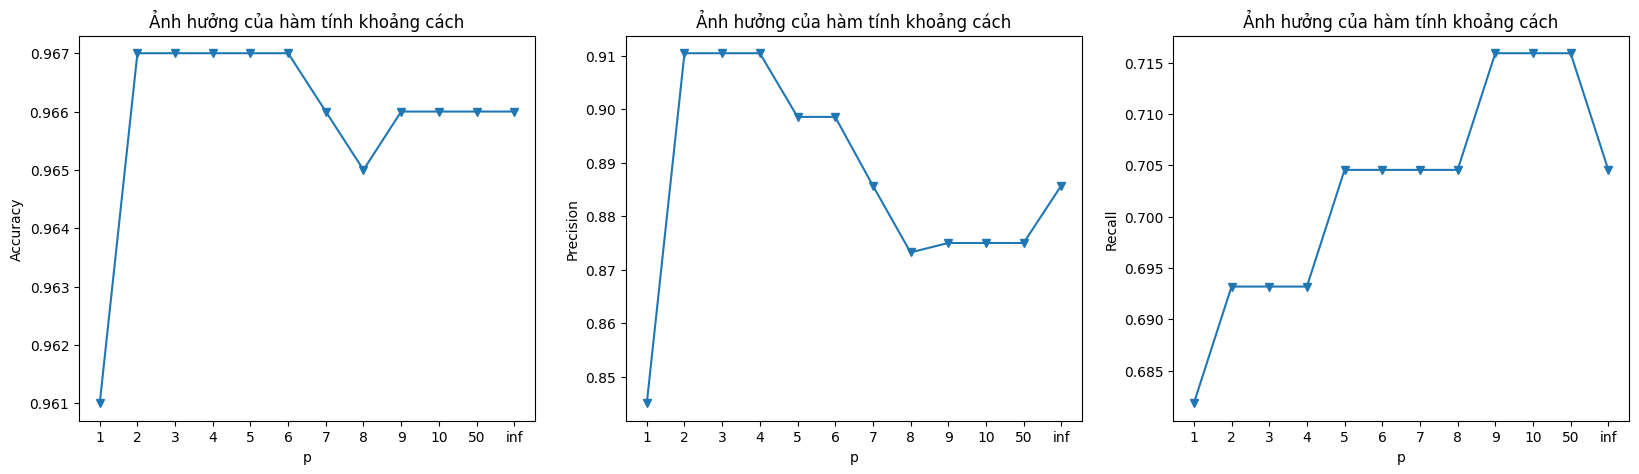

In [32]:
fig,axs = plt.subplots(1,3,figsize=(20,5))
axs[0].plot(ps, acc_score, marker= "v")
axs[0].set_xlabel("p")
axs[0].set_ylabel("Accuracy")
axs[0].set_title("Ảnh hưởng của hàm tính khoảng cách")

axs[1].plot(ps, pre_score, marker= "v")
axs[1].set_xlabel("p")
axs[1].set_ylabel("Precision")
axs[1].set_title("Ảnh hưởng của hàm tính khoảng cách")

axs[2].plot(ps, re_score,marker="v")
axs[2].set_xlabel("p")
axs[2].set_ylabel("Recall")
axs[2].set_title("Ảnh hưởng của hàm tính khoảng cách")

-> minkowski & P=2 (euclidean)

Solve 10.2 Select attributes

In [36]:
models = []
acc, pre, re = [], [], []
keys = ['None', 'ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family','CCAvg',
'Education', 'Mortgage', 'Securities Account',
'CD Account', 'Online', 'CreditCard']
# keys = ['Age', 'Experience']
for key in keys:
    if key == 'None':
        X = loan_dataset.drop(['Personal Loan', ], axis=1)
    else: 
       X = loan_dataset.drop(['Personal Loan',key],axis=1)
    X = (X-X.min())/(X.max()-X.min())
    y = loan_dataset['Personal Loan']
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=5)
    knn_classifier = KNeighborsClassifier(n_neighbors=2,metric='minkowski',p=2,weights='distance')
    knn_classifier.fit(X_train,y_train)
    y_pred = knn_classifier.predict(X_test)
    acc.append(accuracy_score(y_test,y_pred))
    pre.append(precision_score(y_test,y_pred))
    re.append(recall_score(y_test,y_pred))

C:\Users\bpscm\AppData\Local\Temp\ipykernel_16056\1242012000.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(keys, rotation=45)
C:\Users\bpscm\AppData\Local\Temp\ipykernel_16056\1242012000.py:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_xticklabels(keys, rotation=45)
C:\Users\bpscm\AppData\Local\Temp\ipykernel_16056\1242012000.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[2].set_xticklabels(keys, rotation=45)


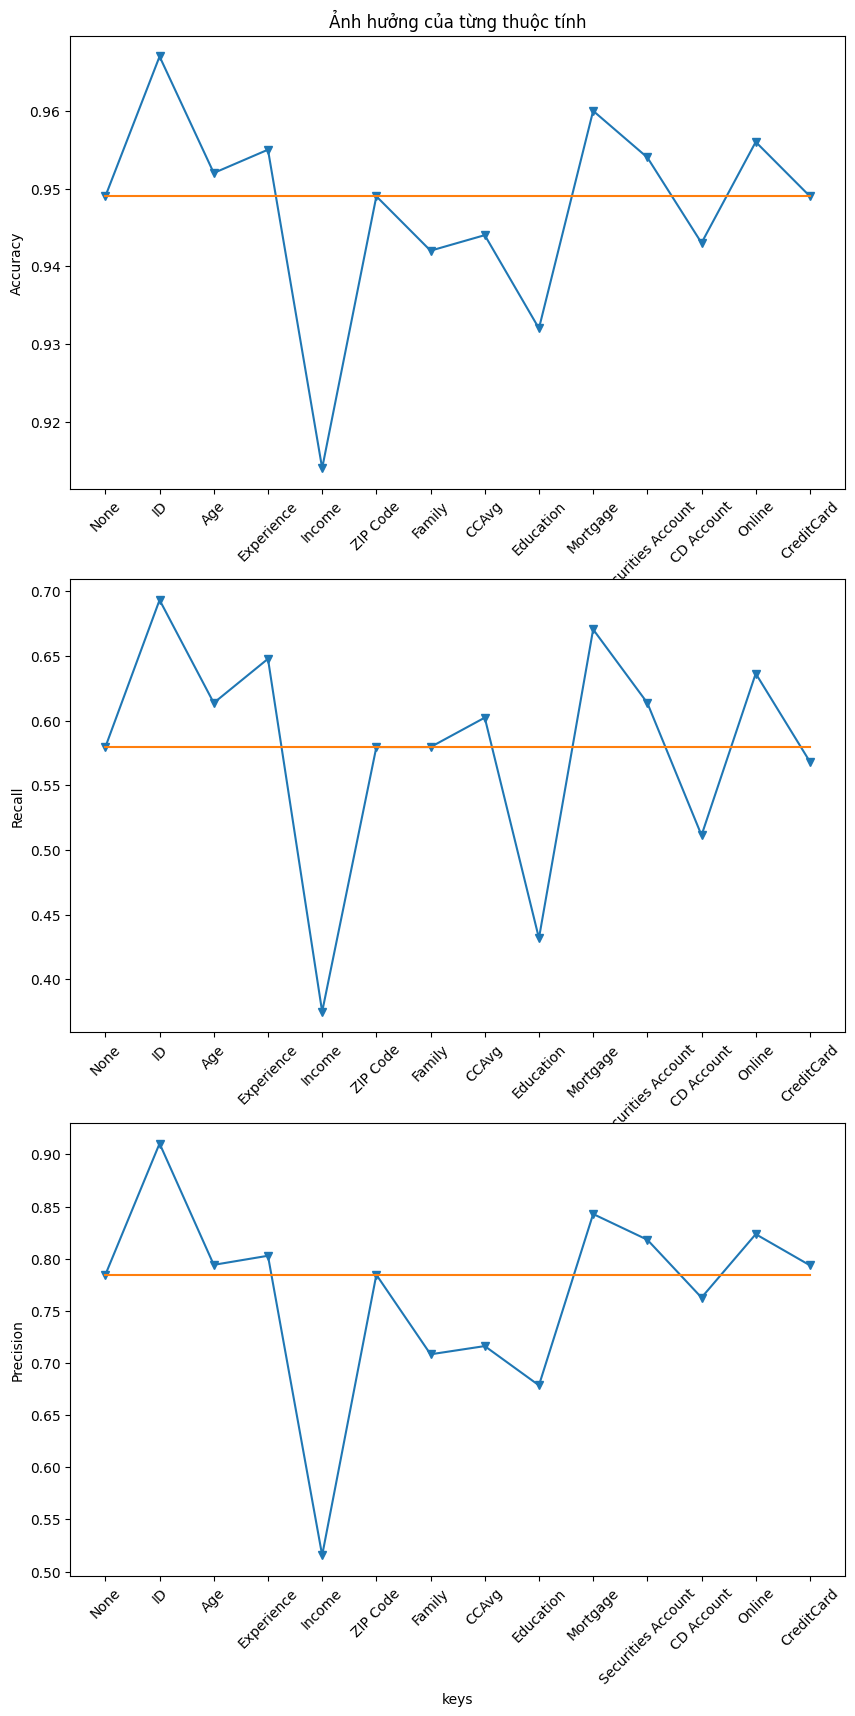

In [35]:
# Visualize
fig, axs = plt.subplots(3, 1, figsize = (10, 20))
axs[0].plot(keys, acc, marker= "v")
axs[0].set_xlabel("keys")
axs[0].set_ylabel("Accuracy")
axs[0].set_title("Ảnh hưởng của từng thuộc tính")
axs[0].plot(keys, [acc[0] for _ in range(len(acc))], marker = '', label ='Baseline')
axs[0].set_xticklabels(keys, rotation=45)
axs[1].plot(keys, re, marker= "v")
axs[1].set_xlabel("keys")
axs[1].set_ylabel("Recall")
# axs[1].set_title("Ảnh hưởng của hàm tính khoảng cách")
axs[1].plot(keys, [re[0] for _ in range(len(re))], marker = '', label ='Baseline')
axs[1].set_xticklabels(keys, rotation=45)
axs[2].plot(keys, pre, marker= "v")
axs[2].set_xlabel("keys")
axs[2].set_ylabel("Precision")
# axs[2].set_title("Ảnh hưởng của hàm tính khoảng cách")
axs[2].plot(keys, [pre[0] for _ in range(len(pre))], marker = '', label ='Baseline')
axs[2].set_xticklabels(keys, rotation=45)
plt.show()

-> Drop attributes that without them, score is higher or equal the orange line: ID, Age,Experience,ZIP Code, Mortgage, Securities Account, Online, Credit Card

In [37]:
X = loan_dataset.drop(['Personal Loan',
                        'ID',
                        'Age',
                        'Experience',
                        'ZIP Code',
                        'Mortgage',
                        'Securities Account',
                        'Online',
                        'CreditCard'], axis=1)
X = (X-X.min())/(X.max()-X.min())
y = loan_dataset['Personal Loan']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
knn_classifier = KNeighborsClassifier(n_neighbors = 2, metric = 'minkowski', p = 2, weights = 'distance')
knn_classifier.fit(X_train, y_train)
print("Testing...\n")
y_pred_knn = knn_classifier.predict(X_test)
print('Accuracy: ', accuracy_score(y_test, y_pred_knn))
print('Precision: ', precision_score(y_test, y_pred_knn))
print('Recall: ', recall_score(y_test, y_pred_knn))

Testing...

Accuracy:  0.986
Precision:  0.9512195121951219
Recall:  0.8863636363636364


-> Much better 

## 11. **Other**

Naive Bayes Classifier

In [39]:
from sklearn.naive_bayes import GaussianNB
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
y_pred_nb = nb_classifier.predict(X_test)
print('Accracy: ', accuracy_score(y_test, y_pred_nb))
print('Precision: ', precision_score(y_test, y_pred_nb))
print('Recall: ', recall_score(y_test, y_pred_nb))

Accracy:  0.9
Precision:  0.44339622641509435
Recall:  0.5340909090909091


Support Vector Classifier

In [41]:
from sklearn import svm
svm_classifier = svm.SVC(kernel='linear')
svm_classifier.fit(X_train, y_train)
y_pred_svm = svm_classifier.predict(X_test)
print('Accuracy: ', accuracy_score(y_test, y_pred_svm))
print('Precision: ', precision_score(y_test, y_pred_svm))
print('Recall: ', recall_score(y_test, y_pred_svm))

Accuracy:  0.95
Precision:  0.8275862068965517
Recall:  0.5454545454545454


Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
lr_classifier = LogisticRegression(random_state=0)
lr_classifier.fit(X_train, y_train)
y_pred_lr = lr_classifier.predict(X_test)
print('Accuracy: ', accuracy_score(y_test, y_pred_lr))
print('Precision: ', precision_score(y_test, y_pred_lr))
print('Recall: ', recall_score(y_test, y_pred_lr))

Accuracy:  0.949
Precision:  0.8245614035087719
Recall:  0.5340909090909091


Decision Tree Classifier

In [43]:
from sklearn.tree import DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 51)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
print('Accuracy: ', accuracy_score(y_test, y_pred_dt))
print('Precision: ', precision_score(y_test, y_pred_dt))
print('Recall: ', recall_score(y_test, y_pred_dt))

Accuracy:  0.981
Precision:  0.9156626506024096
Recall:  0.8636363636363636


Random Forest Classifier

In [44]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators = 20, criterion ='entropy', random_state = 51)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)
print('Accuracy: ', accuracy_score(y_test, y_pred_rf))
print('Precision: ', precision_score(y_test, y_pred_rf))
print('Recall: ', recall_score(y_test, y_pred_rf))

Accuracy:  0.987
Precision:  0.9518072289156626
Recall:  0.8977272727272727
